Classificatore basato su SVM lineari e n-grammi.
 Il secondo classificatore dovrà anch'esso basarsi su un SVM lineare, ma
utilizzando una rappresentazione del testo fondata su n-grammi di
caratteri, parole e part-of-speech. Lo studente dovrà:

 sperimentare diverse configurazioni della rappresentazione testuale,
variando sia la lunghezza degli n-grammi sia il tipo di informazione
linguistica impiegata (forme, lemmi, caratteri, POS);

 confrontare le prestazioni delle diverse configurazioni sul validation
set;

 selezionare il sistema più performante e valutarlo sul test set.


In [ ]:
import numpy as np
import os

In [ ]:
conllu_dataset = "/content/drive/MyDrive/LC2 progetto/linguisticProfiling/dataset/"

In [ ]:
class Document:

    def __init__(self, document_path):
        self.document_path = document_path
        self.doc_id = None
        self.split = None
        self.autore = None
        self._load_doc_info(document_path)
        self.sentences = []
        self.features = None

    # Estraggo le informazioni dal nomed el file
    def _load_doc_info(self, document_path):
        self.doc_id = (document_path.split('.')[0]).split("/")[-1]
        self.split = self.doc_id.split('_')[-1]
        self.autore = self.doc_id.split('_')[0]

    # aggiunge la frase
    def add_sentence(self, sentence):
        self.sentences.append(sentence)

    # calcola il numero di token
    def get_num_tokens(self):
        num_words = 0
        for sentence in self.sentences:
            num_words = num_words + sentence.get_num_tokens()
        return num_words
    # e di caratteri
    def get_num_chars(self):
        num_chars = 0
        for sentence in self.sentences:
            sentence_char_len = sentence.get_num_chars()
            num_chars = num_chars + sentence_char_len
        return num_chars

# classe frasu
class Sentence:

    def __init__(self):
        self.tokens = []

    # aggiunge un token alla frase
    def add_token(self, token):
        self.tokens.append(token)

    # metodi per ottenere parole, lemmi, pos, n-token e n-caratteri

    def get_words(self):
        return [token.word for token in self.tokens]

    def get_lemmas(self):
        return [token.lemma for token in self.tokens]

    def get_pos(self):
        return [token.pos for token in self.tokens]

    def get_num_tokens(self):
        return len(self.tokens)

    def get_num_chars(self):
        num_chars = 0
        for token in self.tokens:
            num_chars = num_chars + token.get_num_chars()
        num_chars = num_chars + self.get_num_tokens() - 1 # contiamo anche gli spazi
        return num_chars

    # stampa
    def __str__(self):
        return ' '.join([token.word for token in self.tokens])

class Token:

    def __init__(self, word, lemma, pos):
        self.word = word
        self.lemma = lemma
        self.pos = pos

    # numero di caratteri
    def get_num_chars(self):
        return len(self.word)

In [ ]:
# caricamento delle frasi nel documento
def load_document_sentences(document):
    sentence = Sentence()
    for line in open(document.document_path, 'r'):
        if line[0].isdigit():  # se la riga inizia con un numero sono in corrispondenza di un token
            splitted_line = line.strip().split('\t')
            if '-' not in splitted_line[0]:  # se l'id della parola non contiene un trattino
                # creo il token
                token = Token(splitted_line[1], splitted_line[2], splitted_line[3])
                sentence.add_token(token)
        if line == '\n':  # se la riga è vuota significa che la frase è finita
            document.add_sentence(sentence)
            sentence = Sentence()

In [ ]:
lista_documenti = []

# cerco ricorsivamente i file conllu
for cartella, sottocartelle, files in os.walk(conllu_dataset):
    for file in files:
        if file.endswith(".conllu"):
            file_path = cartella+"/"+file
            document = Document(file_path)
            load_document_sentences(document)
            lista_documenti.append(document)

In [ ]:
sample_document = lista_documenti[0]
for sentence in sample_document.sentences[:5]:
    tokens = [token.word for token in sentence.tokens]
    print(' - '.join(tokens)+'\n')

I - am - glad - to - recollect - that - when - the - carrier - began - to - move - , - my - mother - ran - out - at - the - gate - , - and - called - to - him - to - stop - , - that - she - might - kiss - me - once - more - .

I - am - glad - to - dwell - upon - the - earnestness - and - love - with - which - she - lifted - up - her - face - to - mine - , - and - did - so - .



estrazione n-grammi (features)


In [ ]:
# Prendiamo come feature di un documento il numero di
# occorrenze dei suoi n-grammi. Questi n-grammi possono
# essere estratti a partire da:
# Caratteri
# Forme
# Lemmi
# POS
sample_sentence = sample_document.sentences[1]
print(sample_sentence)

I am glad to dwell upon the earnestness and love with which she lifted up her face to mine , and did so .


In [ ]:
def extract_word_ngrams_from_sentence(word_ngrams, sentence, el, n):
    # creiamo una lista con tutte le parole
    if el == 'word':
        all_words = sentence.get_words()
    elif el == 'lemma':
        all_words = sentence.get_lemmas()
    elif el == 'pos':
        all_words = sentence.get_pos()
    else:
        raise Exception(f'Invalid element {el}')

    # scorriamo la lista delle parole ed estraiamo gli n-grammi
    for i in range(0, len(all_words) - n + 1): # -n+1 serve per non uscire dal vettore
        ngram_words = all_words[i: i + n]
        ngram = f'{el.upper()}_{n}_' + '_'.join(ngram_words)
        # print(f'{i}: {ngram_words} -> {ngram}')
        if ngram not in word_ngrams:
            word_ngrams[ngram] = 1
        else:
            word_ngrams[ngram] += 1

    return word_ngrams

In [ ]:
# se cambio 1 con 2 ottengo i bigrammi
extract_word_ngrams_from_sentence(dict(), sample_sentence, 'word', 1);

In [ ]:
# ora facccio la stessa cosa per i caratteri
def extract_char_ngrams_from_sentence(char_ngrams, sentence, n):
    # creiamo una lista con tutte le parole
    all_words = sentence.get_words()

    # creiamo una stringa che contenga tutte le parole separate tra spazi perchè vogliamo scorrere i caratteri
    all_words = ' '.join(all_words)

    # scorriamo la stringa ed estraiamo gli n-grammi di caratteri
    for i in range(0, len(all_words) - n + 1):
        ngram_chars = all_words[i:i + n]
        ngram = f'CHAR_{n}_' + ngram_chars

        if ngram not in char_ngrams:
            char_ngrams[ngram] = 1
        else:
            char_ngrams[ngram] += 1

    return char_ngrams

In [ ]:
extract_char_ngrams_from_sentence(dict(), sample_sentence, 1);

estrazione delle features dei documenti

In [ ]:
print(sample_document.features)

None


In [ ]:
def extract_documents_ngrams(all_documents):
    for document in all_documents:
        document_ngrams = dict()
        for sentence in document.sentences:
            extract_word_ngrams_from_sentence(document_ngrams, sentence, 'word', 1)
            extract_word_ngrams_from_sentence(document_ngrams, sentence, 'word', 2)
            extract_char_ngrams_from_sentence(document_ngrams, sentence, 1)
            extract_char_ngrams_from_sentence(document_ngrams, sentence, 2)

        document.features = document_ngrams

In [ ]:
extract_documents_ngrams(lista_documenti)

In [ ]:
sample_document.features;

funzione di normalizzazione - Dividiamo il numero di occorrenze di ogni feature, per la lunghezza del documento.

In [ ]:
# utile perché i paragrafi hanno lunghezza differente
# (normalizza sulla frequenza)
def normalize_ngrams(ngrams_dict, doc_len):
    for ngram in ngrams_dict:
        ngrams_dict[ngram] = ngrams_dict[ngram] / float(doc_len)

In [ ]:
# Estrae e normalizza n-grammi dai documenti.
def extract_documents_ngrams_normalized(all_documents, lista_features):

    for document in all_documents:
        dizionario_features = dict()

        for tipologia, cardinalità in lista_features:
            dizionario_el = dict()

            # Ciclo su tutte le frasi del documento
            for sentence in document.sentences:
                if tipologia == "char":
                    extract_char_ngrams_from_sentence(dizionario_el, sentence, cardinalità)
                    num_elements = document.get_num_chars()
                else:
                    extract_word_ngrams_from_sentence(dizionario_el, sentence, tipologia, cardinalità)
                    num_elements = document.get_num_tokens()

            # Normalizza le feature estratte per questa tipologia
            normalize_ngrams(dizionario_el, num_elements)

            # Aggiunge le feature estratte al dizionario completo del documento
            dizionario_features |= dizionario_el  # Operatore | più chiaro

        document.features = dizionario_features


In [ ]:
lista_features = [("word", 1), ("word", 2), ("char", 1), ("char", 2)]
extract_documents_ngrams_normalized(lista_documenti, lista_features)
sample_document.features
#### Divisione training, test e validation set
def train_test_val_split(all_documents):
    train_features_dict, train_labels = [], []
    test_features_dict, test_labels = [], []
    val_features_dict, val_labels = [], []

    for document in all_documents:
        if document.split == 'training':
            train_features_dict.append(document.features)
            train_labels.append(document.autore)
        elif document.split == 'validation':
            val_features_dict.append(document.features)
            val_labels.append(document.autore)
        else:
            test_features_dict.append(document.features)
            test_labels.append(document.autore)

    return train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels
train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels = train_test_val_split(lista_documenti)
len(train_features_dict), len(train_labels), len(test_features_dict), len(test_labels), len(val_features_dict), len(val_labels)

train_labels[:5]
#### Filtro delle features poco frequenti
#Per ridurre lo spazio delle features (n-grammi) si possono eliminare tutte quelle che compaiono in meno di tot. documenti.
#Il filtro deve essere calcolato sulle features del training set!
def get_num_features(features_dict):
    all_features = set()
    for document_feats in features_dict:
        all_features.update(list(document_feats.keys()))
    return len(all_features)
get_num_features(train_features_dict)
print(f'Numero features: {get_num_features(train_features_dict)}')
def filter_features(train_features_dict, min_occurrences):
    # contiamo ogni feature in quanti documenti diversi compare
    features_counter = dict()
    for document_features_dict in train_features_dict:
        for feature in document_features_dict:
            if feature in features_counter:
                features_counter[feature] += 1
            else:
                features_counter[feature] = 1

    # per ogni user, togliamo le features che compaiono in meno di "min_occurrences" documenti
    for document_features_dict in train_features_dict:
        document_features = list(document_features_dict.keys())
        for feature in document_features:
            if features_counter[feature] < min_occurrences:
                document_features_dict.pop(feature)

    return train_features_dict
train_features_dict = filter_features(train_features_dict, 5)
print(f'Numero features dopo il filtro: {get_num_features(train_features_dict)}')
#### Creazione del vettore delle features
#Trasformare il dizionario di features in un vettore di lunghezza fissa, che abbia una posizione fissa per ogni feature che compare nel training set. Serve una funzione che mappi ogni feature del dizionario ad una posizione sul vettore.
from sklearn.feature_extraction import DictVectorizer

vectorizer = DictVectorizer()
X_train = vectorizer.fit_transform(train_features_dict)
y_train = np.array(train_labels)
X_train
vectorizer.get_feature_names_out(X_train).tolist()
### Normalizzazione delle features
#Utilizzando una matrice sparsa non possiamo usare MinMaxScaler, perchè è importante mantenere la posizione degli 0. Il MinMaxScaler spingerebbe a 0 elementi che non erano 0, e renderebbe diversi da 0 quelli che invece lo erano.
#Utilizziamo MaxAbsScaler che divide ogni feature per il suo massimo in valore assoluto. Le feature non saranno più nell'intervallo [0, 1], ma [-1, 1], e preserveranno la posizione degli 0.
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
scaled_X_train = scaler.fit_transform(X_train)
### Addestramento del classificatore
from sklearn.svm import LinearSVC

svc = LinearSVC(dual=True, max_iter=10000)
svc.fit(scaled_X_train, train_labels)
### Prestazioni sul Validation set
X_val = vectorizer.transform(val_features_dict)
scaled_X_val = scaler.transform(X_val)
y_val = np.array(val_labels)
from sklearn.metrics import classification_report

val_predictions = svc.predict(scaled_X_val)
print(classification_report(val_labels, val_predictions, zero_division=0))

Numero features: 93446
Numero features dopo il filtro: 9689
              precision    recall  f1-score   support

      austen       0.70      0.89      0.78       100
     dickens       0.67      0.45      0.54       100
       woolf       0.65      0.69      0.67       100

    accuracy                           0.68       300
   macro avg       0.67      0.68      0.66       300
weighted avg       0.67      0.68      0.66       300



In [ ]:
lista_features = [("word", 1), ("word", 2), ("pos", 1), ("pos", 2)]
extract_documents_ngrams_normalized(lista_documenti, lista_features)
sample_document.features
#### Divisione training, test e validation set
def train_test_val_split(all_documents):
    train_features_dict, train_labels = [], []
    test_features_dict, test_labels = [], []
    val_features_dict, val_labels = [], []

    for document in all_documents:
        if document.split == 'training':
            train_features_dict.append(document.features)
            train_labels.append(document.autore)
        elif document.split == 'validation':
            val_features_dict.append(document.features)
            val_labels.append(document.autore)
        else:
            test_features_dict.append(document.features)
            test_labels.append(document.autore)

    return train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels
train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels = train_test_val_split(lista_documenti)
len(train_features_dict), len(train_labels), len(test_features_dict), len(test_labels), len(val_features_dict), len(val_labels)

train_labels[:5]
#### Filtro delle features poco frequenti
#Per ridurre lo spazio delle features (n-grammi) si possono eliminare tutte quelle che compaiono in meno di tot. documenti.
#Il filtro deve essere calcolato sulle features del training set!
def get_num_features(features_dict):
    all_features = set()
    for document_feats in features_dict:
        all_features.update(list(document_feats.keys()))
    return len(all_features)
get_num_features(train_features_dict)
print(f'Numero features: {get_num_features(train_features_dict)}')
def filter_features(train_features_dict, min_occurrences):
    # contiamo ogni feature in quanti documenti diversi compare
    features_counter = dict()
    for document_features_dict in train_features_dict:
        for feature in document_features_dict:
            if feature in features_counter:
                features_counter[feature] += 1
            else:
                features_counter[feature] = 1

    # per ogni user, togliamo le features che compaiono in meno di "min_occurrences" documenti
    for document_features_dict in train_features_dict:
        document_features = list(document_features_dict.keys())
        for feature in document_features:
            if features_counter[feature] < min_occurrences:
                document_features_dict.pop(feature)

    return train_features_dict
train_features_dict = filter_features(train_features_dict, 5)
print(f'Numero features dopo il filtro: {get_num_features(train_features_dict)}')
#### Creazione del vettore delle features
#Trasformare il dizionario di features in un vettore di lunghezza fissa, che abbia una posizione fissa per ogni feature che compare nel training set. Serve una funzione che mappi ogni feature del dizionario ad una posizione sul vettore.
from sklearn.feature_extraction import DictVectorizer

vectorizer = DictVectorizer()
X_train = vectorizer.fit_transform(train_features_dict)
y_train = np.array(train_labels)
X_train
vectorizer.get_feature_names_out(X_train).tolist()
### Normalizzazione delle features
#Utilizzando una matrice sparsa non possiamo usare MinMaxScaler, perchè è importante mantenere la posizione degli 0. Il MinMaxScaler spingerebbe a 0 elementi che non erano 0, e renderebbe diversi da 0 quelli che invece lo erano.
#Utilizziamo MaxAbsScaler che divide ogni feature per il suo massimo in valore assoluto. Le feature non saranno più nell'intervallo [0, 1], ma [-1, 1], e preserveranno la posizione degli 0.
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
scaled_X_train = scaler.fit_transform(X_train)
### Addestramento del classificatore
from sklearn.svm import LinearSVC

svc = LinearSVC(dual=True, max_iter=10000)
svc.fit(scaled_X_train, train_labels)
### Prestazioni sul Validation set
X_val = vectorizer.transform(val_features_dict)
scaled_X_val = scaler.transform(X_val)
y_val = np.array(val_labels)
from sklearn.metrics import classification_report

val_predictions = svc.predict(scaled_X_val)
print(classification_report(val_labels, val_predictions, zero_division=0))

Numero features: 92645
Numero features dopo il filtro: 9137
              precision    recall  f1-score   support

      austen       0.71      0.88      0.79       100
     dickens       0.62      0.48      0.54       100
       woolf       0.70      0.69      0.70       100

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.67       300
weighted avg       0.68      0.68      0.67       300



In [ ]:
lista_features = [("pos", 1), ("pos", 2), ("char", 1), ("char", 2)]
extract_documents_ngrams_normalized(lista_documenti, lista_features)
sample_document.features
#### Divisione training, test e validation set
def train_test_val_split(all_documents):
    train_features_dict, train_labels = [], []
    test_features_dict, test_labels = [], []
    val_features_dict, val_labels = [], []

    for document in all_documents:
        if document.split == 'training':
            train_features_dict.append(document.features)
            train_labels.append(document.autore)
        elif document.split == 'validation':
            val_features_dict.append(document.features)
            val_labels.append(document.autore)
        else:
            test_features_dict.append(document.features)
            test_labels.append(document.autore)

    return train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels
train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels = train_test_val_split(lista_documenti)
len(train_features_dict), len(train_labels), len(test_features_dict), len(test_labels), len(val_features_dict), len(val_labels)

train_labels[:5]
#### Filtro delle features poco frequenti
#Per ridurre lo spazio delle features (n-grammi) si possono eliminare tutte quelle che compaiono in meno di tot. documenti.
#Il filtro deve essere calcolato sulle features del training set!
def get_num_features(features_dict):
    all_features = set()
    for document_feats in features_dict:
        all_features.update(list(document_feats.keys()))
    return len(all_features)
get_num_features(train_features_dict)
print(f'Numero features: {get_num_features(train_features_dict)}')
def filter_features(train_features_dict, min_occurrences):
    # contiamo ogni feature in quanti documenti diversi compare
    features_counter = dict()
    for document_features_dict in train_features_dict:
        for feature in document_features_dict:
            if feature in features_counter:
                features_counter[feature] += 1
            else:
                features_counter[feature] = 1

    # per ogni user, togliamo le features che compaiono in meno di "min_occurrences" documenti
    for document_features_dict in train_features_dict:
        document_features = list(document_features_dict.keys())
        for feature in document_features:
            if features_counter[feature] < min_occurrences:
                document_features_dict.pop(feature)

    return train_features_dict
train_features_dict = filter_features(train_features_dict, 5)
print(f'Numero features dopo il filtro: {get_num_features(train_features_dict)}')
#### Creazione del vettore delle features
#Trasformare il dizionario di features in un vettore di lunghezza fissa, che abbia una posizione fissa per ogni feature che compare nel training set. Serve una funzione che mappi ogni feature del dizionario ad una posizione sul vettore.
from sklearn.feature_extraction import DictVectorizer

vectorizer = DictVectorizer()
X_train = vectorizer.fit_transform(train_features_dict)
y_train = np.array(train_labels)
X_train
vectorizer.get_feature_names_out(X_train).tolist()
### Normalizzazione delle features
#Utilizzando una matrice sparsa non possiamo usare MinMaxScaler, perchè è importante mantenere la posizione degli 0. Il MinMaxScaler spingerebbe a 0 elementi che non erano 0, e renderebbe diversi da 0 quelli che invece lo erano.
#Utilizziamo MaxAbsScaler che divide ogni feature per il suo massimo in valore assoluto. Le feature non saranno più nell'intervallo [0, 1], ma [-1, 1], e preserveranno la posizione degli 0.
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
scaled_X_train = scaler.fit_transform(X_train)
### Addestramento del classificatore
from sklearn.svm import LinearSVC

svc = LinearSVC(dual=True, max_iter=10000)
svc.fit(scaled_X_train, train_labels)
### Prestazioni sul Validation set
X_val = vectorizer.transform(val_features_dict)
scaled_X_val = scaler.transform(X_val)
y_val = np.array(val_labels)
from sklearn.metrics import classification_report

val_predictions = svc.predict(scaled_X_val)
print(classification_report(val_labels, val_predictions, zero_division=0))

Numero features: 1353
Numero features dopo il filtro: 1038
              precision    recall  f1-score   support

      austen       0.63      0.70      0.66       100
     dickens       0.51      0.38      0.44       100
       woolf       0.56      0.64      0.60       100

    accuracy                           0.57       300
   macro avg       0.57      0.57      0.57       300
weighted avg       0.57      0.57      0.57       300



In [ ]:
lista_features = [("word", 1), ("word", 2), ("lemma", 1), ("lemma", 2)]
extract_documents_ngrams_normalized(lista_documenti, lista_features)
sample_document.features
#### Divisione training, test e validation set
def train_test_val_split(all_documents):
    train_features_dict, train_labels = [], []
    test_features_dict, test_labels = [], []
    val_features_dict, val_labels = [], []

    for document in all_documents:
        if document.split == 'training':
            train_features_dict.append(document.features)
            train_labels.append(document.autore)
        elif document.split == 'validation':
            val_features_dict.append(document.features)
            val_labels.append(document.autore)
        else:
            test_features_dict.append(document.features)
            test_labels.append(document.autore)

    return train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels
train_features_dict, train_labels, test_features_dict, test_labels, val_features_dict, val_labels = train_test_val_split(lista_documenti)
len(train_features_dict), len(train_labels), len(test_features_dict), len(test_labels), len(val_features_dict), len(val_labels)

train_labels[:5]
#### Filtro delle features poco frequenti
#Per ridurre lo spazio delle features (n-grammi) si possono eliminare tutte quelle che compaiono in meno di tot. documenti.
#Il filtro deve essere calcolato sulle features del training set!
def get_num_features(features_dict):
    all_features = set()
    for document_feats in features_dict:
        all_features.update(list(document_feats.keys()))
    return len(all_features)
get_num_features(train_features_dict)
print(f'Numero features: {get_num_features(train_features_dict)}')
def filter_features(train_features_dict, min_occurrences):
    # contiamo ogni feature in quanti documenti diversi compare
    features_counter = dict()
    for document_features_dict in train_features_dict:
        for feature in document_features_dict:
            if feature in features_counter:
                features_counter[feature] += 1
            else:
                features_counter[feature] = 1

    # per ogni user, togliamo le features che compaiono in meno di "min_occurrences" documenti
    for document_features_dict in train_features_dict:
        document_features = list(document_features_dict.keys())
        for feature in document_features:
            if features_counter[feature] < min_occurrences:
                document_features_dict.pop(feature)

    return train_features_dict
train_features_dict = filter_features(train_features_dict, 5)
print(f'Numero features dopo il filtro: {get_num_features(train_features_dict)}')
#### Creazione del vettore delle features
#Trasformare il dizionario di features in un vettore di lunghezza fissa, che abbia una posizione fissa per ogni feature che compare nel training set. Serve una funzione che mappi ogni feature del dizionario ad una posizione sul vettore.
from sklearn.feature_extraction import DictVectorizer

vectorizer = DictVectorizer()
X_train = vectorizer.fit_transform(train_features_dict)
y_train = np.array(train_labels)
X_train
vectorizer.get_feature_names_out(X_train).tolist()
### Normalizzazione delle features
#Utilizzando una matrice sparsa non possiamo usare MinMaxScaler, perchè è importante mantenere la posizione degli 0. Il MinMaxScaler spingerebbe a 0 elementi che non erano 0, e renderebbe diversi da 0 quelli che invece lo erano.
#Utilizziamo MaxAbsScaler che divide ogni feature per il suo massimo in valore assoluto. Le feature non saranno più nell'intervallo [0, 1], ma [-1, 1], e preserveranno la posizione degli 0.
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
scaled_X_train = scaler.fit_transform(X_train)
### Addestramento del classificatore
from sklearn.svm import LinearSVC

svc = LinearSVC(dual=True, max_iter=10000)
svc.fit(scaled_X_train, train_labels)
### Prestazioni sul Validation set
X_val = vectorizer.transform(val_features_dict)
scaled_X_val = scaler.transform(X_val)
y_val = np.array(val_labels)
from sklearn.metrics import classification_report

val_predictions = svc.predict(scaled_X_val)
print(classification_report(val_labels, val_predictions, zero_division=0))

Numero features: 171716
Numero features dopo il filtro: 17474
              precision    recall  f1-score   support

      austen       0.75      0.88      0.81       100
     dickens       0.64      0.53      0.58       100
       woolf       0.69      0.68      0.68       100

    accuracy                           0.70       300
   macro avg       0.69      0.70      0.69       300
weighted avg       0.69      0.70      0.69       300



ora sul test di quella più performante (parola - lemma ha avuto accuracy del .70)

In [ ]:
X_test = vectorizer.transform(test_features_dict)
scaled_X_test = scaler.transform(X_test)
y_test = np.array(test_labels)

In [ ]:
from sklearn.metrics import classification_report

test_predictions = svc.predict(scaled_X_test)
print(classification_report(test_labels, test_predictions, zero_division=0))

              precision    recall  f1-score   support

      austen       0.80      0.87      0.83       100
     dickens       0.59      0.47      0.53       100
       woolf       0.65      0.73      0.69       100

    accuracy                           0.69       300
   macro avg       0.68      0.69      0.68       300
weighted avg       0.68      0.69      0.68       300



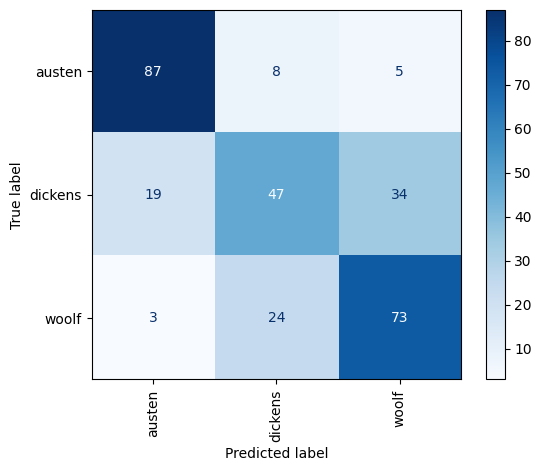

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(test_labels, test_predictions, xticks_rotation='vertical', cmap='Blues')

In [ ]:
svc.classes_

array(['austen', 'dickens', 'woolf'], dtype='<U7')

In [ ]:
coefs = svc.coef_  # ndarray of shape (1, n_features) if n_classes == 2 else (n_classes, n_features)
coefs.shape

(3, 17474)

In [ ]:
features_names = vectorizer.get_feature_names_out(X_train).tolist()
features_names

['LEMMA_1_!',
 'LEMMA_1_"',
 "LEMMA_1_'",
 "LEMMA_1_'s",
 'LEMMA_1_(',
 'LEMMA_1_)',
 'LEMMA_1_,',
 'LEMMA_1_,—',
 'LEMMA_1_-',
 'LEMMA_1_.',
 'LEMMA_1_....',
 'LEMMA_1_:',
 'LEMMA_1_:—',
 'LEMMA_1_;',
 'LEMMA_1_;—',
 'LEMMA_1_?',
 'LEMMA_1_Abbey',
 'LEMMA_1_Allan',
 'LEMMA_1_Ambrose',
 'LEMMA_1_Artful',
 'LEMMA_1_Arthu',
 'LEMMA_1_Arthur',
 'LEMMA_1_Barney',
 'LEMMA_1_Basnett',
 'LEMMA_1_Bates',
 'LEMMA_1_Bedwin',
 'LEMMA_1_Bertram',
 'LEMMA_1_Bertrams',
 'LEMMA_1_Betsy',
 'LEMMA_1_Bill',
 'LEMMA_1_Bolter',
 'LEMMA_1_Brittles',
 'LEMMA_1_Brownlow',
 'LEMMA_1_Bumble',
 'LEMMA_1_Campbell',
 'LEMMA_1_Cassandra',
 'LEMMA_1_Chailey',
 'LEMMA_1_Charles',
 'LEMMA_1_Charley',
 'LEMMA_1_Charlotte',
 'LEMMA_1_Chitling',
 'LEMMA_1_Christmas',
 'LEMMA_1_Churchill',
 'LEMMA_1_Clacton',
 'LEMMA_1_Clarissa',
 'LEMMA_1_Claypole',
 'LEMMA_1_Cole',
 'LEMMA_1_Colonel',
 'LEMMA_1_Corney',
 'LEMMA_1_Cosham',
 'LEMMA_1_Crackit',
 'LEMMA_1_Crawford',
 'LEMMA_1_Crown',
 'LEMMA_1_Dalloway',
 'LEMMA_1_Datchet'

Feature importance classe austen


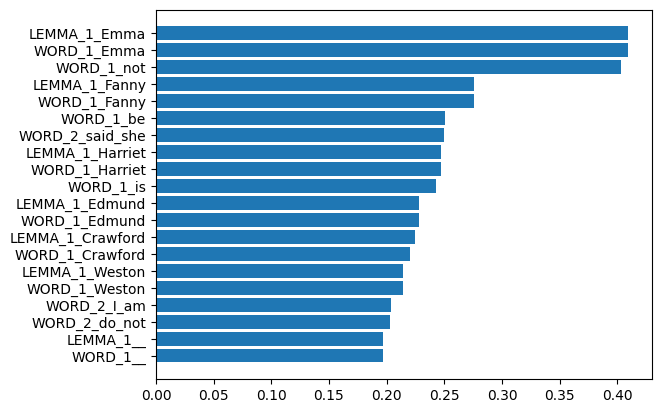

In [ ]:
import matplotlib.pyplot as plt

idx = 0
class_coefs = coefs[idx]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_names, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

# importances, names = zip(*sorted(zip(feature_importance, features)))

num_to_plot = 20
print(f'Feature importance classe {svc.classes_[idx]}')
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align='center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.gca().invert_yaxis()
plt.show()

Feature importance classe dickens


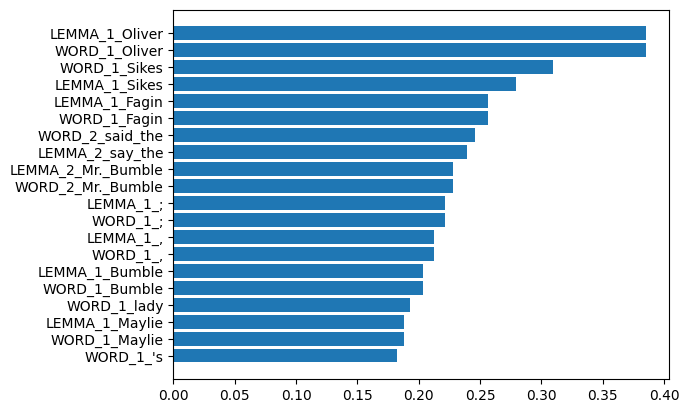

In [ ]:
idx = 1
class_coefs = coefs[idx]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_names, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

# importances, names = zip(*sorted(zip(feature_importance, features)))

num_to_plot = 20
print(f'Feature importance classe {svc.classes_[idx]}')
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align='center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.gca().invert_yaxis()
plt.show()

Feature importance classe woolf


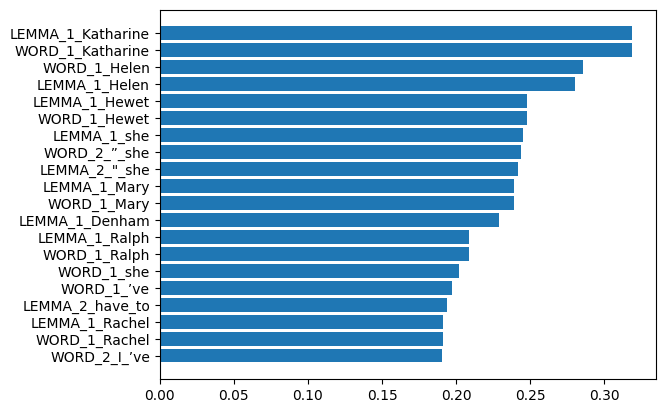

In [ ]:
idx = 2
class_coefs = coefs[idx]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_names, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

# importances, names = zip(*sorted(zip(feature_importance, features)))

num_to_plot = 20
print(f'Feature importance classe {svc.classes_[idx]}')
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align='center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.gca().invert_yaxis()
plt.show()